# Comparación de Modelos con Fashion-MNIST
En este notebook se estudia cómo influyen diferentes configuraciones de una red neuronal profunda sobre el desempeño y tiempo de entrenamiento.  
Usaremos el dataset **Fashion-MNIST**, que contiene imágenes de 28×28 píxeles con 10 categorías de ropa.

In [ ]:
# 1. Importar librerías y cargar el dataset
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

# Limpieza de sesión
keras.backend.clear_session()

# Cargar Fashion-MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalización de píxeles [0, 255] -> [0, 1]
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

# Separar conjunto de validación
x_valid, x_train = x_train_full[:5000], x_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Mostrar forma de los datos
print(f"Forma de los datos:")
print(f"x_train: {x_train.shape}, x_valid: {x_valid.shape}, x_test: {x_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de los datos:
x_train: (55000, 28, 28), x_valid: (5000, 28, 28), x_test: (10000, 28, 28)


## 2. Función para añadir ruido a la imagen y visualizar el efecto del ruido


Generando datos con ruido Salt and Pepper...
Visualizando efecto del ruido...


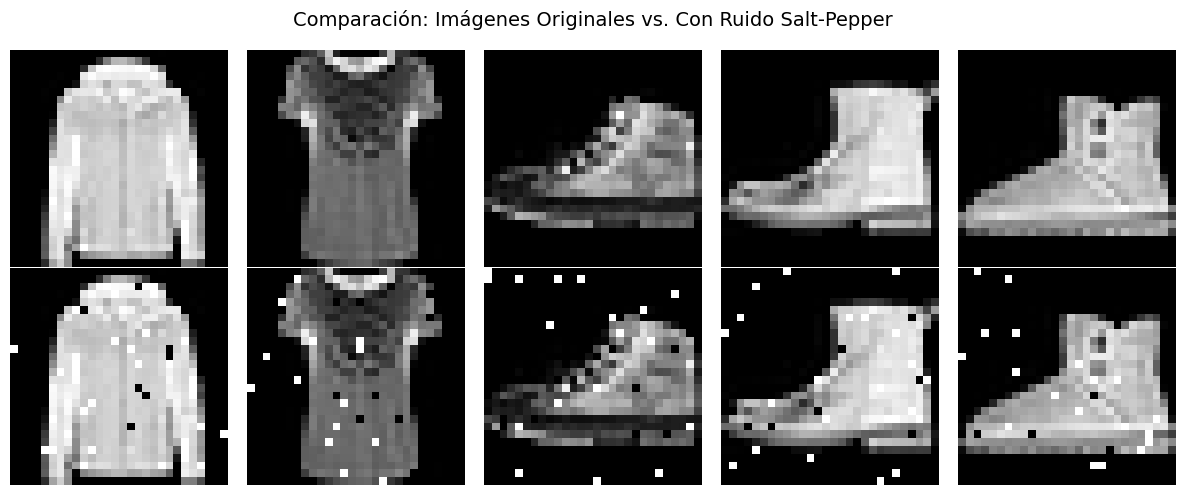

In [ ]:
def add_salt_pepper_noise(data, salt_prob=0.02, pepper_prob=0.02):
    """
    Añade ruido de sal y pimienta a los datos.

    Args:
        data: array de datos de entrada
        salt_prob: probabilidad de añadir píxeles blancos (sal)
        pepper_prob: probabilidad de añadir píxeles negros (pimienta)

    Returns:
        datos con ruido de sal y pimienta añadido
    """
    noisy_data = data.copy()

    # Sal (píxeles blancos = 1.0)
    salt_mask = np.random.random(data.shape) < salt_prob
    noisy_data[salt_mask] = 1.0

    # Pimienta (píxeles negros = 0.0)
    pepper_mask = np.random.random(data.shape) < pepper_prob
    noisy_data[pepper_mask] = 0.0

    return noisy_data

# Generar datos con ruido salt and pepper
print("\nGenerando datos con ruido Salt and Pepper...")
x_train_noisy = add_salt_pepper_noise(x_train, salt_prob=0.02, pepper_prob=0.02)
x_valid_noisy = add_salt_pepper_noise(x_valid, salt_prob=0.01, pepper_prob=0.01)

def visualize_noise_effect(original, noisy, num_samples=5):
    """Visualiza el efecto del ruido en algunas imágenes de muestra"""
    plt.figure(figsize=(12, 5))
    for i in range(num_samples):
        # Imagen original
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(original[i], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel('Originales', fontsize=12)

        # Imagen con ruido
        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(noisy[i], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel('Con Salt-Pepper', fontsize=12)

    plt.suptitle('Comparación: Imágenes Originales vs. Con Ruido Salt-Pepper', fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualizar el efecto del ruido
print("Visualizando efecto del ruido...")
visualize_noise_effect(x_train, x_train_noisy)

## 3. Definir una función auxiliar para construir y entrenar modelos de datos normales y ruidosos
Esta función recibe parámetros como función de activación, optimizador, uso de Batch Normalization y callbacks.


In [ ]:
def build_and_train_model(activation="relu", optimizer="adam", use_batchnorm=False,
                          callbacks=None, epochs=20):
    """
    Construye y entrena un modelo de red neuronal.
    """
    model = keras.models.Sequential()

    # Capa de aplanamiento
    model.add(keras.layers.Flatten(input_shape=[28, 28]))

    # 10 capas densas con 100 neuronas cada una
    for _ in range(10):
        model.add(keras.layers.Dense(100, kernel_initializer="he_normal"))

        if use_batchnorm:
            model.add(keras.layers.BatchNormalization())

        model.add(keras.layers.Activation(activation))

    # Capa de salida
    model.add(keras.layers.Dense(10, activation="softmax"))

    # Compilar modelo
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    # Medir tiempo de entrenamiento
    start_time = time.time()

    # Entrenar modelo
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        validation_data=(x_valid, y_valid),
        callbacks=callbacks,
        verbose=0
    )

    end_time = time.time()
    duration = end_time - start_time
    val_acc = max(history.history["val_accuracy"])

    return model, duration, val_acc

# ============================================================================
# FUNCIÓN PARA CONSTRUIR Y ENTRENAR MODELOS CON DATOS RUIDOSOS
# ============================================================================

def build_and_train_model_with_noise(activation="relu", optimizer="adam",
                                      use_batchnorm=False, callbacks=None,
                                      epochs=20, use_noisy_data=False):
    """
    Construye y entrena un modelo, opcionalmente usando datos con ruido.
    """
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[28, 28]))

    for _ in range(10):
        model.add(keras.layers.Dense(100, kernel_initializer="he_normal"))

        if use_batchnorm:
            model.add(keras.layers.BatchNormalization())

        model.add(keras.layers.Activation(activation))

    model.add(keras.layers.Dense(10, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    start_time = time.time()

    # Seleccionar datos con o sin ruido
    train_x = x_train_noisy if use_noisy_data else x_train
    valid_x = x_valid_noisy if use_noisy_data else x_valid

    history = model.fit(
        train_x, y_train,
        epochs=epochs,
        validation_data=(valid_x, y_valid),
        callbacks=callbacks,
        verbose=0
    )

    end_time = time.time()
    duration = end_time - start_time
    val_acc = max(history.history["val_accuracy"])

    return model, duration, val_acc

## 4. Definir configuraciones de 8 modelos propuestos
Cada modelo tendrá una combinación distinta de parámetros.


In [ ]:
# Callbacks comunes
early_stopping = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

configs = [
    {
        "name": "Modelo 1 - ReLU + Adam",
        "activation": "relu",
        "optimizer": keras.optimizers.Adam(learning_rate=1e-3),
        "use_batchnorm": False,
        "callbacks": [early_stopping],
        "use_noise": False
    },
    {
        "name": "Modelo 2 - ReLU + Nadam",
        "activation": "relu",
        "optimizer": keras.optimizers.Nadam(learning_rate=5e-4, beta_1=0.9, beta_2=0.999),
        "use_batchnorm": False,
        "callbacks": [early_stopping],
        "use_noise": False
    },
    {
        "name": "Modelo 3 - ELU + Adam",
        "activation": "elu",
        "optimizer": keras.optimizers.Adam(learning_rate=1e-3),
        "use_batchnorm": False,
        "callbacks": [early_stopping],
        "use_noise": False
    },
    {
        "name": "Modelo 4 - ELU + Nadam",
        "activation": "elu",
        "optimizer": keras.optimizers.Nadam(learning_rate=5e-4, beta_1=0.9, beta_2=0.999),
        "use_batchnorm": False,
        "callbacks": [early_stopping],
        "use_noise": False
    },
    {
        "name": "Modelo 5 - tanh + SGD",
        "activation": "tanh",
        "optimizer": keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
        "use_batchnorm": False,
        "callbacks": [early_stopping],
        "use_noise": False
    },
    {
        "name": "Modelo 6 - ReLU + RMSprop + BatchNorm",
        "activation": "relu",
        "optimizer": keras.optimizers.RMSprop(learning_rate=1e-3),
        "use_batchnorm": True,
        "callbacks": [early_stopping],
        "use_noise": False
    },
    {
        "name": "Modelo 7 - ELU + Nadam + BatchNorm",
        "activation": "elu",
        "optimizer": keras.optimizers.Nadam(learning_rate=5e-4, beta_1=0.9, beta_2=0.999),
        "use_batchnorm": True,
        "callbacks": [early_stopping],
        "use_noise": False
    },
    {
        "name": "Modelo 8 - ReLU + Adam + Salt-Pepper Noise",
        "activation": "relu",
        "optimizer": keras.optimizers.Adam(learning_rate=1e-3),
        "use_batchnorm": False,
        "callbacks": [early_stopping],
        "use_noise": True
    }
]

## 5. Entrenar los modelos y recopilar resultados


In [ ]:
results = []
for i, cfg in enumerate(configs, 1):
    print(f"\n[{i}/{len(configs)}] Entrenando {cfg['name']}...")

    if cfg["use_noise"]:
        # Entrenar con datos ruidosos
        model, duration, val_acc = build_and_train_model_with_noise(
            activation=cfg["activation"],
            optimizer=cfg["optimizer"],
            use_batchnorm=cfg["use_batchnorm"],
            callbacks=cfg["callbacks"],
            epochs=30,
            use_noisy_data=True
        )
    else:
        # Entrenar con datos normales
        model, duration, val_acc = build_and_train_model(
            activation=cfg["activation"],
            optimizer=cfg["optimizer"],
            use_batchnorm=cfg["use_batchnorm"],
            callbacks=cfg["callbacks"],
            epochs=30
        )

    # Evaluar en el conjunto de test (sin ruido)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "Modelo": cfg["name"],
        "Tiempo (s)": round(duration, 2),
        "Val_Accuracy (%)": round(val_acc * 100, 2),
        "Test_Accuracy (%)": round(test_acc * 100, 2)
    })

    print(f"Val Accuracy: {val_acc*100:.2f}%  |  Test Accuracy: {test_acc*100:.2f}%  |  Tiempo: {duration:.2f}s")


[1/8] Entrenando Modelo 1 - ReLU + Adam...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Val Accuracy: 89.72%  |  Test Accuracy: 87.86%  |  Tiempo: 246.41s

[2/8] Entrenando Modelo 2 - ReLU + Nadam...
Val Accuracy: 89.80%  |  Test Accuracy: 88.33%  |  Tiempo: 404.07s

[3/8] Entrenando Modelo 3 - ELU + Adam...
Val Accuracy: 89.84%  |  Test Accuracy: 88.96%  |  Tiempo: 325.81s

[4/8] Entrenando Modelo 4 - ELU + Nadam...


## 6. Comparar resultados de todos los modelos


In [ ]:
print("\n" + "="*70)
print("RESULTADOS COMPARATIVOS DE TODOS LOS MODELOS")
print("="*70)

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

print("\n" + "="*70)

# Identificar el mejor modelo
best_test = df_results.loc[df_results['Test_Accuracy (%)'].idxmax()]
print(f"\nMEJOR MODELO (Test Accuracy): {best_test['Modelo']}")
print(f"Test Accuracy: {best_test['Test_Accuracy (%)']}%")
print(f"Val Accuracy: {best_test['Val_Accuracy (%)']}%")
print(f"Tiempo: {best_test['Tiempo (s)']}s")



## 7. Visualizar comparación


In [ ]:
plt.figure(figsize=(10,5))
plt.bar(df_results["Modelo"], df_results["Tiempo (s)"], color="lightgreen")
plt.title("Comparación de Tiempos de Entrenamiento", fontsize=14)
plt.ylabel("Tiempo (segundos)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


In [ ]:
# Gráfico de comparación
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy de validación
axes[0].barh(df_results['Modelo'], df_results['Val_Accuracy (%)'], color='steelblue')
axes[0].set_xlabel('Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Precisión en Validación', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Accuracy de test
axes[1].barh(df_results['Modelo'], df_results['Test_Accuracy (%)'], color='darkorange')
axes[1].set_xlabel('Test Accuracy (%)', fontsize=12)
axes[1].set_title('Precisión en Test', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Tiempo de entrenamiento
axes[2].barh(df_results['Modelo'], df_results['Tiempo (s)'], color='forestgreen')
axes[2].set_xlabel('Tiempo (segundos)', fontsize=12)
axes[2].set_title('Tiempo de Entrenamiento', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEntrenamiento completado!")

## 8. Análisis visual del aprendizaje de los modelos

A continuación, graficamos las curvas de **precisión (accuracy)** y **precisión de validación (val_accuracy)** durante el entrenamiento de cada modelo.  
Esto permite observar:

- La **estabilidad** del aprendizaje.  
- Si un modelo sufre de **sobreajuste (overfitting)**.  
- La **velocidad de convergencia** de cada configuración.  


In [ ]:
# Reentrenar y guardar historial completo para graficar comparaciones
histories = {}
for cfg in configs:
    print(f"Entrenando {cfg['name']} para análisis visual...")
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[28, 28]))
    for _ in range(3):
        model.add(keras.layers.Dense(128, kernel_initializer="he_normal"))
        if cfg["use_batchnorm"]:
            model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation(cfg["activation"]))
    model.add(keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=cfg["optimizer"],
                  metrics=["accuracy"])
    history = model.fit(
        x_train, y_train,
        epochs=30,
        validation_data=(x_valid, y_valid),
        callbacks=cfg["callbacks"],
        verbose=0
    )
    histories[cfg["name"]] = history
